# 02 Data Assessing - Assessment Terpisah per Dataset

Notebook ini melakukan assessment kualitas data untuk 8 dataset raw secara terpisah. Semua output ditampilkan inline dan tidak disimpan ke file.


## Setup Environment
Import library dipisahkan dari konfigurasi, catalog, loader, dan function assessment.


In [1]:
import re
from datetime import datetime
from pathlib import Path
from zipfile import ZipFile
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

try:
    from fingo_ds1.config import RAW_DATA_PATH
except ImportError:
    RAW_DATA_PATH = None


## Konfigurasi Path dan Tampilan
Sel ini hanya menyiapkan lokasi project, lokasi data raw, dan opsi tampilan notebook.


In [2]:
project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent

if RAW_DATA_PATH is None:
    RAW_DATA_PATH = project_root / 'data' / 'raw'

raw_data_path = Path(RAW_DATA_PATH)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 120)
sns.set_theme(style='whitegrid', palette='Set2')

print(f'Project root  : {project_root}')
print(f'Raw data path : {raw_data_path}')
print('Mode output   : display-only, tidak menyimpan file')


Project root  : /home/umaygans/05_nayyara_submission_1/nayyara_capstone
Raw data path : /home/umaygans/05_nayyara_submission_1/nayyara_capstone/data/raw
Mode output   : display-only, tidak menyimpan file


## Dataset Catalog
Catalog dibuat eksplisit agar assessment selalu jelas membaca 8 dataset yang sama.


In [3]:
DATASET_CATALOG = [
    {
        'dataset_id': 'ecommerce_2024_01_january',
        'dataset_name': 'E-Commerce Sales - January 2024',
        'domain': 'ecommerce_sales',
        'dataset_period': '2024-01',
        'source_path': raw_data_path / 'Indonesian_Ecommerce_sales' / '01_JanuarySales2024_clean.xlsx',
    },
    {
        'dataset_id': 'ecommerce_2024_06_june',
        'dataset_name': 'E-Commerce Sales - June 2024',
        'domain': 'ecommerce_sales',
        'dataset_period': '2024-06',
        'source_path': raw_data_path / 'Indonesian_Ecommerce_sales' / '02_JuneSales2024_clean.xlsx',
    },
    {
        'dataset_id': 'ecommerce_2024_12_december',
        'dataset_name': 'E-Commerce Sales - December 2024',
        'domain': 'ecommerce_sales',
        'dataset_period': '2024-12',
        'source_path': raw_data_path / 'Indonesian_Ecommerce_sales' / '03_DecemberSales2024_clean.xlsx',
    },
    {
        'dataset_id': 'ecommerce_2025_02_february',
        'dataset_name': 'E-Commerce Sales - February 2025',
        'domain': 'ecommerce_sales',
        'dataset_period': '2025-02',
        'source_path': raw_data_path / 'Indonesian_Ecommerce_sales' / '04_FebruarySales2025_clean.xlsx',
    },
    {
        'dataset_id': 'ecommerce_2025_07_july',
        'dataset_name': 'E-Commerce Sales - July 2025',
        'domain': 'ecommerce_sales',
        'dataset_period': '2025-07',
        'source_path': raw_data_path / 'Indonesian_Ecommerce_sales' / '05_JulySales2025_clean.xlsx',
    },
    {
        'dataset_id': 'ecommerce_2025_11_november',
        'dataset_name': 'E-Commerce Sales - November 2025',
        'domain': 'ecommerce_sales',
        'dataset_period': '2025-11',
        'source_path': raw_data_path / 'Indonesian_Ecommerce_sales' / '06_NovemberSales2025_clean.xlsx',
    },
    {
        'dataset_id': 'daily_household_transactions',
        'dataset_name': 'Daily Household Transactions',
        'domain': 'household_finance',
        'dataset_period': None,
        'source_path': raw_data_path / 'daily_household_transaction' / 'Daily Household Transactions.csv',
    },
    {
        'dataset_id': 'personal_finance',
        'dataset_name': 'Personal Finance Dataset',
        'domain': 'personal_finance',
        'dataset_period': None,
        'source_path': raw_data_path / 'personal_finance' / 'Personal_Finance_Dataset.csv',
    },
]

assert len(DATASET_CATALOG) == 8, 'Catalog harus berisi tepat 8 dataset.'


## Reusable Loader
Helper ini membaca CSV dan Excel serta menambahkan metadata sumber data.


In [4]:
SUPPORTED_EXTENSIONS = {'.csv', '.xlsx', '.xls'}
EXCEL_NAMESPACE = {'main': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}


def make_unique_columns(columns):
    counts = {}
    clean_columns = []

    for column in columns:
        text = '' if pd.isna(column) else str(column).strip()
        text = text or 'unnamed_column'
        counts[text] = counts.get(text, 0) + 1
        clean_columns.append(text if counts[text] == 1 else f'{text}_{counts[text]}')

    return clean_columns


def excel_column_index(cell_reference):
    letters = ''.join(character for character in str(cell_reference) if character.isalpha()) or 'A'
    index = 0

    for letter in letters.upper():
        index = index * 26 + ord(letter) - ord('A') + 1

    return index - 1


def read_excel_without_engine(file_path):
    with ZipFile(file_path) as archive:
        names = set(archive.namelist())
        shared_strings = []

        if 'xl/sharedStrings.xml' in names:
            root = ET.fromstring(archive.read('xl/sharedStrings.xml'))
            shared_strings = [
                ''.join(text.text or '' for text in item.findall('.//main:t', EXCEL_NAMESPACE))
                for item in root.findall('main:si', EXCEL_NAMESPACE)
            ]

        worksheet_names = sorted(name for name in names if name.startswith('xl/worksheets/sheet') and name.endswith('.xml'))
        if not worksheet_names:
            return pd.DataFrame()

        sheet = ET.fromstring(archive.read(worksheet_names[0]))
        rows = []
        width = 0

        for row in sheet.findall('.//main:sheetData/main:row', EXCEL_NAMESPACE):
            values = []
            for cell in row.findall('main:c', EXCEL_NAMESPACE):
                column_index = excel_column_index(cell.attrib.get('r', 'A1'))
                while len(values) <= column_index:
                    values.append(np.nan)

                cell_type = cell.attrib.get('t')
                if cell_type == 'inlineStr':
                    value = ''.join(text.text or '' for text in cell.findall('.//main:t', EXCEL_NAMESPACE))
                else:
                    raw_value = cell.find('main:v', EXCEL_NAMESPACE)
                    value = raw_value.text if raw_value is not None else np.nan
                    if cell_type == 's' and pd.notna(value):
                        value = shared_strings[int(value)]

                values[column_index] = value

            width = max(width, len(values))
            rows.append(values)

    if not rows:
        return pd.DataFrame()

    rows = [row + [np.nan] * (width - len(row)) for row in rows]
    columns = make_unique_columns(rows[0])
    return pd.DataFrame(rows[1:], columns=columns).replace(r'^\s*$', np.nan, regex=True)


def read_data_file(file_path):
    file_path = Path(file_path)
    suffix = file_path.suffix.lower()

    if suffix not in SUPPORTED_EXTENSIONS:
        raise ValueError(f'Unsupported file extension: {file_path.suffix}')

    if suffix == '.csv':
        return pd.read_csv(file_path, sep=None, engine='python', encoding='utf-8-sig').replace(r'^\s*$', np.nan, regex=True)

    try:
        return pd.read_excel(file_path).replace(r'^\s*$', np.nan, regex=True)
    except ImportError:
        return read_excel_without_engine(file_path)


def relative_to_project(path):
    path = Path(path)
    try:
        return str(path.relative_to(project_root))
    except ValueError:
        return str(path)


## Validasi Dataset Catalog
Preview catalog memastikan semua file raw tersedia sebelum assessment dijalankan.


In [5]:
def build_catalog_preview(catalog):
    return pd.DataFrame(
        {
            'dataset_id': item['dataset_id'],
            'dataset_name': item['dataset_name'],
            'domain': item['domain'],
            'dataset_period': item['dataset_period'],
            'source_path': relative_to_project(item['source_path']),
            'file_exists': item['source_path'].exists(),
            'file_size_kb': round(item['source_path'].stat().st_size / 1024, 2) if item['source_path'].exists() else np.nan,
        }
        for item in catalog
    )


catalog_preview = build_catalog_preview(DATASET_CATALOG)
display(catalog_preview)

missing_files = catalog_preview.loc[~catalog_preview['file_exists'], 'source_path'].tolist()
if missing_files:
    raise FileNotFoundError(f'File raw tidak ditemukan: {missing_files}')


,dataset_id,dataset_name,domain,dataset_period,source_path,file_exists,file_size_kb
0,ecommerce_2024_01_january,E-Commerce Sales - January 2024,ecommerce_sales,2024-01,data/raw/Indonesian_Ecommerce_sales/01_January...,True,42.92
1,ecommerce_2024_06_june,E-Commerce Sales - June 2024,ecommerce_sales,2024-06,data/raw/Indonesian_Ecommerce_sales/02_JuneSal...,True,65.45
2,ecommerce_2024_12_december,E-Commerce Sales - December 2024,ecommerce_sales,2024-12,data/raw/Indonesian_Ecommerce_sales/03_Decembe...,True,101.40
3,ecommerce_2025_02_february,E-Commerce Sales - February 2025,ecommerce_sales,2025-02,data/raw/Indonesian_Ecommerce_sales/04_Februar...,True,89.67
4,ecommerce_2025_07_july,E-Commerce Sales - July 2025,ecommerce_sales,2025-07,data/raw/Indonesian_Ecommerce_sales/05_JulySal...,True,65.19
5,ecommerce_2025_11_november,E-Commerce Sales - November 2025,ecommerce_sales,2025-11,data/raw/Indonesian_Ecommerce_sales/06_Novembe...,True,103.07
6,daily_household_transactions,Daily Household Transactions,household_finance,None,data/raw/daily_household_transaction/Daily Hou...,True,185.50
7,personal_finance,Personal Finance Dataset,personal_finance,None,data/raw/personal_finance/Personal_Finance_Dat...,True,89.40


## Load Raw Dataset
Function `load_raw_datasets()` membuat `raw_datasets`, `manifest_df`, dan `dataset_catalog` yang dipakai oleh assessment.


In [6]:
def attach_source_metadata(frame, meta):
    dataset_id = meta['dataset_id']
    enriched = frame.copy()
    enriched['_dataset_id'] = dataset_id
    enriched['_dataset_name'] = meta['dataset_name']
    enriched['_domain'] = meta['domain']
    enriched['_dataset_period'] = meta['dataset_period']
    enriched['_source_file'] = meta['source_path'].name
    enriched['_source_path'] = relative_to_project(meta['source_path'])
    return enriched


def build_manifest_row(frame, meta):
    return {
        'dataset_id': meta['dataset_id'],
        'dataset_name': meta['dataset_name'],
        'domain': meta['domain'],
        'dataset_period': meta['dataset_period'],
        'source_path': relative_to_project(meta['source_path']),
        'record_count': int(len(frame)),
        'column_count': int(frame.shape[1]),
    }


def load_raw_datasets(catalog):
    datasets = {}
    manifest_rows = []

    for meta in catalog:
        dataset_id = meta['dataset_id']
        frame = attach_source_metadata(read_data_file(meta['source_path']), meta)
        datasets[dataset_id] = frame
        manifest_rows.append(build_manifest_row(frame, meta))
        print(f'{dataset_id}: {frame.shape[0]:,} rows x {frame.shape[1]:,} columns')

    manifest = pd.DataFrame(manifest_rows)
    reusable_catalog = [{**meta, 'source_path': relative_to_project(meta['source_path'])} for meta in catalog]
    return datasets, manifest, reusable_catalog


In [7]:
raw_datasets, manifest_df, dataset_catalog = load_raw_datasets(DATASET_CATALOG)
display(manifest_df)

print(f'\nTotal dataset loaded: {len(raw_datasets)}')


ecommerce_2024_01_january: 431 rows x 24 columns
ecommerce_2024_06_june: 697 rows x 24 columns


ecommerce_2024_12_december: 1,214 rows x 23 columns


ecommerce_2025_02_february: 957 rows x 24 columns
ecommerce_2025_07_july: 766 rows x 23 columns


ecommerce_2025_11_november: 1,131 rows x 24 columns
daily_household_transactions: 2,461 rows x 14 columns
personal_finance: 1,500 rows x 11 columns


,dataset_id,dataset_name,domain,dataset_period,source_path,record_count,column_count
0,ecommerce_2024_01_january,E-Commerce Sales - January 2024,ecommerce_sales,2024-01,data/raw/Indonesian_Ecommerce_sales/01_January...,431,24
1,ecommerce_2024_06_june,E-Commerce Sales - June 2024,ecommerce_sales,2024-06,data/raw/Indonesian_Ecommerce_sales/02_JuneSal...,697,24
2,ecommerce_2024_12_december,E-Commerce Sales - December 2024,ecommerce_sales,2024-12,data/raw/Indonesian_Ecommerce_sales/03_Decembe...,1214,23
3,ecommerce_2025_02_february,E-Commerce Sales - February 2025,ecommerce_sales,2025-02,data/raw/Indonesian_Ecommerce_sales/04_Februar...,957,24
4,ecommerce_2025_07_july,E-Commerce Sales - July 2025,ecommerce_sales,2025-07,data/raw/Indonesian_Ecommerce_sales/05_JulySal...,766,23
5,ecommerce_2025_11_november,E-Commerce Sales - November 2025,ecommerce_sales,2025-11,data/raw/Indonesian_Ecommerce_sales/06_Novembe...,1131,24
6,daily_household_transactions,Daily Household Transactions,household_finance,None,data/raw/daily_household_transaction/Daily Hou...,2461,14
7,personal_finance,Personal Finance Dataset,personal_finance,None,data/raw/personal_finance/Personal_Finance_Dat...,1500,11



Total dataset loaded: 8


## Konfigurasi Kolom Assessment
Candidate column dipisahkan dari function supaya mudah ditambah jika schema data berubah.


In [8]:
COLUMN_CANDIDATES = {
    'date': ['date', 'waktu_pesanan_dibuat', 'transaction_date', 'order_date'],
    'amount': ['amount', 'total_pembayaran', 'total_payment', 'payment_amount'],
    'category': ['category', 'product_categories', 'product_category', 'subcategory'],
    'description': ['transaction_description', 'description', 'note', 'order_id'],
    'transaction_type': ['type', 'income_expense', 'income/expense', 'status_pesanan'],
    'status': ['status_pesanan'],
    'payment_method': ['metode_pembayaran', 'mode', 'payment_method'],
    'city': ['kota_kabupaten', 'city'],
    'province': ['provinsi', 'province'],
    'quantity': ['total_qty', 'quantity'],
    'order_id': ['order_id'],
}


## Helper Assessment
Function berikut menangani deteksi kolom, parsing tanggal/amount, missing value, outlier, dan konversi tipe output.


In [9]:
def normalize_name(value):
    text = str(value).strip().lower()
    text = re.sub(r'[/\\]+', '_', text)
    text = re.sub(r'[^0-9a-zA-Z]+', '_', text)
    return text.strip('_')


def find_column(frame, candidates):
    lookup = {normalize_name(column): column for column in frame.columns}
    normalized_candidates = [normalize_name(candidate) for candidate in candidates]

    for candidate in normalized_candidates:
        if candidate in lookup:
            return lookup[candidate]

    for candidate in normalized_candidates:
        for normalized_column, original_column in lookup.items():
            if candidate and candidate in normalized_column:
                return original_column

    return None


def detect_columns(frame):
    return {name: find_column(frame, candidates) for name, candidates in COLUMN_CANDIDATES.items()}


def parse_mixed_dates(series):
    values = series.astype('string').str.strip().replace({'': pd.NA, 'nan': pd.NA, 'None': pd.NA})

    try:
        parsed = pd.to_datetime(values, errors='coerce', format='mixed', dayfirst=True)
    except TypeError:
        parsed = pd.to_datetime(values, errors='coerce', dayfirst=True)

    numeric_values = pd.to_numeric(values, errors='coerce')
    excel_serial_mask = parsed.isna() & numeric_values.between(20000, 80000)
    if excel_serial_mask.any():
        parsed.loc[excel_serial_mask] = pd.to_datetime(
            numeric_values.loc[excel_serial_mask], unit='D', origin='1899-12-30', errors='coerce'
        )

    return parsed


def parse_amount(series):
    values = series.astype('string').str.strip()
    values = values.str.replace(r'\s+', '', regex=True)
    values = values.str.replace(r'(?<=\d),(?=\d{3}(\D|$))', '', regex=True)
    values = values.str.replace(',', '.', regex=False)
    values = values.str.replace(r'[^0-9.\-]', '', regex=True)
    values = values.replace({'': np.nan, 'nan': np.nan, 'None': np.nan, '<NA>': np.nan})
    return pd.to_numeric(values, errors='coerce')


def build_missing_summary(frame):
    if frame.empty:
        return pd.DataFrame(columns=['column', 'missing_count', 'missing_pct', 'present_count'])

    missing = frame.isna().sum()
    return (
        pd.DataFrame(
            {
                'column': frame.columns,
                'missing_count': missing.values.astype(int),
                'missing_pct': (missing / len(frame) * 100).round(2).values,
                'present_count': (len(frame) - missing.values).astype(int),
            }
        )
        .sort_values(['missing_pct', 'missing_count'], ascending=False)
        .reset_index(drop=True)
    )


def detect_outliers_iqr(series):
    values = series.dropna()
    if len(values) < 4:
        return pd.Series(False, index=series.index), np.nan, np.nan

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return (series < lower_bound) | (series > upper_bound), lower_bound, upper_bound


def to_python(value):
    if isinstance(value, dict):
        return {key: to_python(item) for key, item in value.items()}
    if isinstance(value, list):
        return [to_python(item) for item in value]
    if isinstance(value, tuple):
        return [to_python(item) for item in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return None if np.isnan(value) else float(value)
    if isinstance(value, (pd.Timestamp, datetime)):
        return None if pd.isna(value) else value.isoformat()
    if pd.isna(value):
        return None
    return value


def period_to_series(meta, index):
    period = meta.get('dataset_period')
    if not period:
        return pd.Series(pd.NaT, index=index)
    return pd.Series(pd.to_datetime(f'{period}-01', errors='coerce'), index=index)


## Function Assessment Dataset
`assess_dataset()` hanya menilai satu dataframe sehingga bisa dipakai ulang untuk dataset baru.


In [10]:
def assess_dataset(dataset_id, frame, meta):
    detected = detect_columns(frame)
    missing_summary = build_missing_summary(frame)

    date_column = detected['date']
    if date_column:
        parsed_dates = parse_mixed_dates(frame[date_column])
        date_source = 'source_column'
    elif meta.get('dataset_period'):
        parsed_dates = period_to_series(meta, frame.index)
        date_source = 'dataset_period_from_filename'
    else:
        parsed_dates = pd.Series(pd.NaT, index=frame.index)
        date_source = 'not_available'

    amount_column = detected['amount']
    amount_values = parse_amount(frame[amount_column]) if amount_column else pd.Series(np.nan, index=frame.index)
    outlier_mask, outlier_lower, outlier_upper = detect_outliers_iqr(amount_values)

    category_column = detected['category']
    category_values = frame[category_column].astype('string').str.strip() if category_column else pd.Series(pd.NA, index=frame.index)
    top_categories = category_values.value_counts(dropna=True).head(10).to_dict()

    key_columns = [column for column in [date_column, amount_column, category_column] if column]
    subset_duplicates = int(frame.duplicated(subset=key_columns, keep=False).sum()) if len(key_columns) >= 2 else 0

    valid_dates = parsed_dates.dropna()
    valid_amounts = amount_values.dropna()
    today = pd.Timestamp.today().normalize()

    critical_missing = {
        'date': {
            'source': date_source,
            'count': int(parsed_dates.isna().sum()),
            'percentage': round(float(parsed_dates.isna().mean() * 100), 2) if len(frame) else 0.0,
        },
        'amount': {
            'source': amount_column,
            'count': int(amount_values.isna().sum()),
            'percentage': round(float(amount_values.isna().mean() * 100), 2) if len(frame) else 0.0,
        },
        'category': {
            'source': category_column,
            'count': int(category_values.isna().sum()),
            'percentage': round(float(category_values.isna().mean() * 100), 2) if len(frame) else 0.0,
        },
    }

    issue_summary = []
    if critical_missing['date']['percentage'] > 10:
        issue_summary.append('Tanggal banyak kosong/tidak valid')
    if critical_missing['amount']['percentage'] > 5:
        issue_summary.append('Amount banyak kosong/tidak valid')
    if int((amount_values < 0).sum()) > 0:
        issue_summary.append('Ada amount negatif')
    if subset_duplicates > 0:
        issue_summary.append('Ada potensi duplikasi berdasarkan key date-amount-category')
    if int(outlier_mask.sum()) > 0:
        issue_summary.append('Ada outlier amount berdasarkan IQR')
    if not issue_summary:
        issue_summary.append('Tidak ada issue besar yang terdeteksi otomatis')

    return {
        'dataset_info': {
            'dataset_id': dataset_id,
            'dataset_name': meta['dataset_name'],
            'domain': meta['domain'],
            'dataset_period': meta.get('dataset_period'),
            'source_path': meta['source_path'],
            'records': int(len(frame)),
            'columns': int(frame.shape[1]),
            'memory_mb': round(float(frame.memory_usage(deep=True).sum() / (1024 ** 2)), 4),
        },
        'schema': {
            'detected_columns': detected,
            'columns': list(frame.columns),
            'dtypes': {column: str(dtype) for column, dtype in frame.dtypes.items()},
        },
        'missing_values': {
            'total_missing_cells': int(frame.isna().sum().sum()),
            'columns_with_missing': int((frame.isna().sum() > 0).sum()),
            'top_missing_columns': missing_summary.head(12).to_dict(orient='records'),
            'critical_missing': critical_missing,
        },
        'date_quality': {
            'date_column': date_column,
            'date_source': date_source,
            'unparseable_dates': int(parsed_dates.isna().sum()),
            'future_dates': int((parsed_dates > today).sum()),
            'min_date': valid_dates.min() if not valid_dates.empty else None,
            'max_date': valid_dates.max() if not valid_dates.empty else None,
        },
        'amount_quality': {
            'amount_column': amount_column,
            'missing_amounts': int(amount_values.isna().sum()),
            'negative_amounts': int((amount_values < 0).sum()),
            'zero_amounts': int((amount_values == 0).sum()),
            'min': valid_amounts.min() if not valid_amounts.empty else None,
            'median': valid_amounts.median() if not valid_amounts.empty else None,
            'mean': valid_amounts.mean() if not valid_amounts.empty else None,
            'max': valid_amounts.max() if not valid_amounts.empty else None,
        },
        'duplicates': {
            'exact_duplicates': int(frame.duplicated().sum()),
            'subset_columns': key_columns,
            'subset_duplicates': subset_duplicates,
            'subset_duplicate_pct': round(float(subset_duplicates / len(frame) * 100), 2) if len(frame) else 0.0,
        },
        'outliers': {
            'method': 'IQR amount',
            'lower_bound': outlier_lower,
            'upper_bound': outlier_upper,
            'count': int(outlier_mask.sum()),
            'percentage': round(float(outlier_mask.sum() / len(frame) * 100), 2) if len(frame) else 0.0,
        },
        'category_quality': {
            'category_column': category_column,
            'unique_categories': int(category_values.nunique(dropna=True)),
            'top_categories': top_categories,
        },
        'issue_summary': issue_summary,
    }


## Jalankan Assessment untuk Tiap Dataset
`run_assessment()` menjalankan assessment per dataset dan membangun summary dataframe.


In [11]:
def build_assessment_summary_row(dataset_id, meta, report):
    return {
        'dataset_id': dataset_id,
        'dataset_name': meta['dataset_name'],
        'records': report['dataset_info']['records'],
        'columns': report['dataset_info']['columns'],
        'missing_cells': report['missing_values']['total_missing_cells'],
        'columns_with_missing': report['missing_values']['columns_with_missing'],
        'date_missing_pct': report['missing_values']['critical_missing']['date']['percentage'],
        'amount_missing_pct': report['missing_values']['critical_missing']['amount']['percentage'],
        'category_missing_pct': report['missing_values']['critical_missing']['category']['percentage'],
        'exact_duplicates': report['duplicates']['exact_duplicates'],
        'subset_duplicates': report['duplicates']['subset_duplicates'],
        'outlier_pct': report['outliers']['percentage'],
        'issue_count': len(report['issue_summary']),
    }


def run_assessment(catalog, datasets):
    reports = {}
    summary_rows = []

    for meta in catalog:
        dataset_id = meta['dataset_id']
        report = assess_dataset(dataset_id, datasets[dataset_id], meta)
        reports[dataset_id] = report
        summary_rows.append(build_assessment_summary_row(dataset_id, meta, report))

    summary = pd.DataFrame(summary_rows).sort_values('dataset_id').reset_index(drop=True)
    return reports, summary


assessment_reports, assessment_summary_df = run_assessment(dataset_catalog, raw_datasets)
display(assessment_summary_df)


,dataset_id,dataset_name,records,columns,missing_cells,columns_with_missing,date_missing_pct,amount_missing_pct,category_missing_pct,exact_duplicates,subset_duplicates,outlier_pct,issue_count
0,daily_household_transactions,Daily Household Transactions,2461,14,3617,3,0.0,0.0,0.0,9,99,12.80,2
1,ecommerce_2024_01_january,E-Commerce Sales - January 2024,431,24,367,1,0.0,0.0,0.0,0,2,8.35,2
2,ecommerce_2024_06_june,E-Commerce Sales - June 2024,697,24,608,1,0.0,0.0,0.0,0,0,10.33,1
3,ecommerce_2024_12_december,E-Commerce Sales - December 2024,1214,23,1047,1,0.0,0.0,0.0,0,559,9.64,2
4,ecommerce_2025_02_february,E-Commerce Sales - February 2025,957,24,835,1,0.0,0.0,0.0,0,0,12.02,1
5,ecommerce_2025_07_july,E-Commerce Sales - July 2025,766,23,676,1,0.0,0.0,0.0,0,374,12.01,2
6,ecommerce_2025_11_november,E-Commerce Sales - November 2025,1131,24,1030,1,0.0,0.0,0.0,0,2,11.05,2
7,personal_finance,Personal Finance Dataset,1500,11,1500,1,0.0,0.0,0.0,0,0,5.87,1


## Detail Assessment Tiap Dataset
Detail display dipisahkan ke function agar bisa dipanggil ulang untuk subset report.


In [12]:
def display_assessment_details(reports, max_missing_columns=8):
    for dataset_id, report in reports.items():
        print('\n' + '=' * 100)
        print(f"{dataset_id} - {report['dataset_info']['dataset_name']}")
        print('=' * 100)
        print('Detected columns:')
        display(pd.DataFrame(report['schema']['detected_columns'].items(), columns=['standard_field', 'detected_column']))

        print('Top missing columns:')
        display(pd.DataFrame(report['missing_values']['top_missing_columns']).head(max_missing_columns))

        print('Top categories:')
        display(pd.Series(report['category_quality']['top_categories'], name='count').to_frame())

        print('Issue summary:')
        for issue in report['issue_summary']:
            print(f'- {issue}')


display_assessment_details(assessment_reports)



ecommerce_2024_01_january - E-Commerce Sales - January 2024
Detected columns:


,standard_field,detected_column
0,date,Waktu Pesanan Dibuat
1,amount,Total Pembayaran
2,category,product_categories
3,description,order_id
4,transaction_type,Status Pesanan
5,status,Status Pesanan
6,payment_method,Metode Pembayaran
7,city,Kota/Kabupaten
8,province,Provinsi
9,quantity,total_qty


Top missing columns:


,column,missing_count,missing_pct,present_count
0,Alasan Pembatalan,367,85.15,64
1,order_id,0,0.00,431
2,total_qty,0,0.00,431
3,total_weight_gr,0,0.00,431
4,total_returned_qty,0,0.00,431
5,Total Diskon,0,0.00,431
6,product_categories,0,0.00,431
7,num_product_categories,0,0.00,431


Top categories:


...

Top missing columns:


,column,missing_count,missing_pct,present_count
0,_dataset_period,1500,100.0,0
1,Date,0,0.0,1500
2,Transaction Description,0,0.0,1500
3,Category,0,0.0,1500
4,Amount,0,0.0,1500
5,Type,0,0.0,1500
6,_dataset_id,0,0.0,1500
7,_dataset_name,0,0.0,1500


Top categories:


,count
Rent,165
Travel,160
Utilities,157
Health & Fitness,152
Shopping,150
Food & Drink,149
Salary,146
Entertainment,143
Investment,142
Other,136


Issue summary:
- Ada outlier amount berdasarkan IQR


## Text Report Helper
`build_text_report()` membuat ringkasan teks dari dictionary assessment.


In [13]:
def build_text_report(reports):
    lines = [
        '=' * 100,
        'DATA QUALITY ASSESSMENT REPORT - 8 DATASET TERPISAH',
        '=' * 100,
        '',
    ]

    for dataset_id, report in reports.items():
        info = report['dataset_info']
        lines.extend(
            [
                f"DATASET: {dataset_id}",
                '-' * 100,
                f"Name            : {info['dataset_name']}",
                f"Rows x Columns  : {info['records']:,} x {info['columns']:,}",
                f"Date Source     : {report['date_quality']['date_source']}",
                f"Date Range      : {to_python(report['date_quality']['min_date'])} to {to_python(report['date_quality']['max_date'])}",
                f"Missing Cells   : {report['missing_values']['total_missing_cells']:,}",
                f"Amount Missing  : {report['missing_values']['critical_missing']['amount']['percentage']}%",
                f"Exact Duplicate : {report['duplicates']['exact_duplicates']:,}",
                f"Key Duplicate   : {report['duplicates']['subset_duplicates']:,}",
                f"Outlier Amount  : {report['outliers']['count']:,} ({report['outliers']['percentage']}%)",
                'Issues:',
            ]
        )
        lines.extend(f'- {issue}' for issue in report['issue_summary'])
        lines.append('')

    lines.append('=' * 100)
    return '\n'.join(lines)


## Display Assessment Report
Report ditampilkan inline dan tidak disimpan ke JSON/CSV/TXT.


In [14]:
print(build_text_report(assessment_reports))
print('\nAssessment display-only; tidak ada file JSON/CSV/TXT yang disimpan.')
display(assessment_summary_df)


DATA QUALITY ASSESSMENT REPORT - 8 DATASET TERPISAH

DATASET: ecommerce_2024_01_january
----------------------------------------------------------------------------------------------------
Name            : E-Commerce Sales - January 2024
Rows x Columns  : 431 x 24
Date Source     : source_column
Date Range      : 2024-01-01T00:05:00 to 2024-01-31T22:56:00
Missing Cells   : 367
Amount Missing  : 0.0%
Exact Duplicate : 0
Key Duplicate   : 2
Outlier Amount  : 36 (8.35%)
Issues:
- Ada potensi duplikasi berdasarkan key date-amount-category
- Ada outlier amount berdasarkan IQR

DATASET: ecommerce_2024_06_june
----------------------------------------------------------------------------------------------------
Name            : E-Commerce Sales - June 2024
Rows x Columns  : 697 x 24
Date Source     : source_column
Date Range      : 2024-06-01T03:22:00 to 2024-06-30T23:36:00
Missing Cells   : 608
Amount Missing  : 0.0%
Exact Duplicate : 0
Key Duplicate   : 0
Outlier Amount  : 72 (10.33%)
Issue

,dataset_id,dataset_name,records,columns,missing_cells,columns_with_missing,date_missing_pct,amount_missing_pct,category_missing_pct,exact_duplicates,subset_duplicates,outlier_pct,issue_count
0,daily_household_transactions,Daily Household Transactions,2461,14,3617,3,0.0,0.0,0.0,9,99,12.80,2
1,ecommerce_2024_01_january,E-Commerce Sales - January 2024,431,24,367,1,0.0,0.0,0.0,0,2,8.35,2
2,ecommerce_2024_06_june,E-Commerce Sales - June 2024,697,24,608,1,0.0,0.0,0.0,0,0,10.33,1
3,ecommerce_2024_12_december,E-Commerce Sales - December 2024,1214,23,1047,1,0.0,0.0,0.0,0,559,9.64,2
4,ecommerce_2025_02_february,E-Commerce Sales - February 2025,957,24,835,1,0.0,0.0,0.0,0,0,12.02,1
5,ecommerce_2025_07_july,E-Commerce Sales - July 2025,766,23,676,1,0.0,0.0,0.0,0,374,12.01,2
6,ecommerce_2025_11_november,E-Commerce Sales - November 2025,1131,24,1030,1,0.0,0.0,0.0,0,2,11.05,2
7,personal_finance,Personal Finance Dataset,1500,11,1500,1,0.0,0.0,0.0,0,0,5.87,1


## Visualisasi Kualitas Data
Visualisasi dibuat dengan `seaborn` dari `assessment_summary_df`.


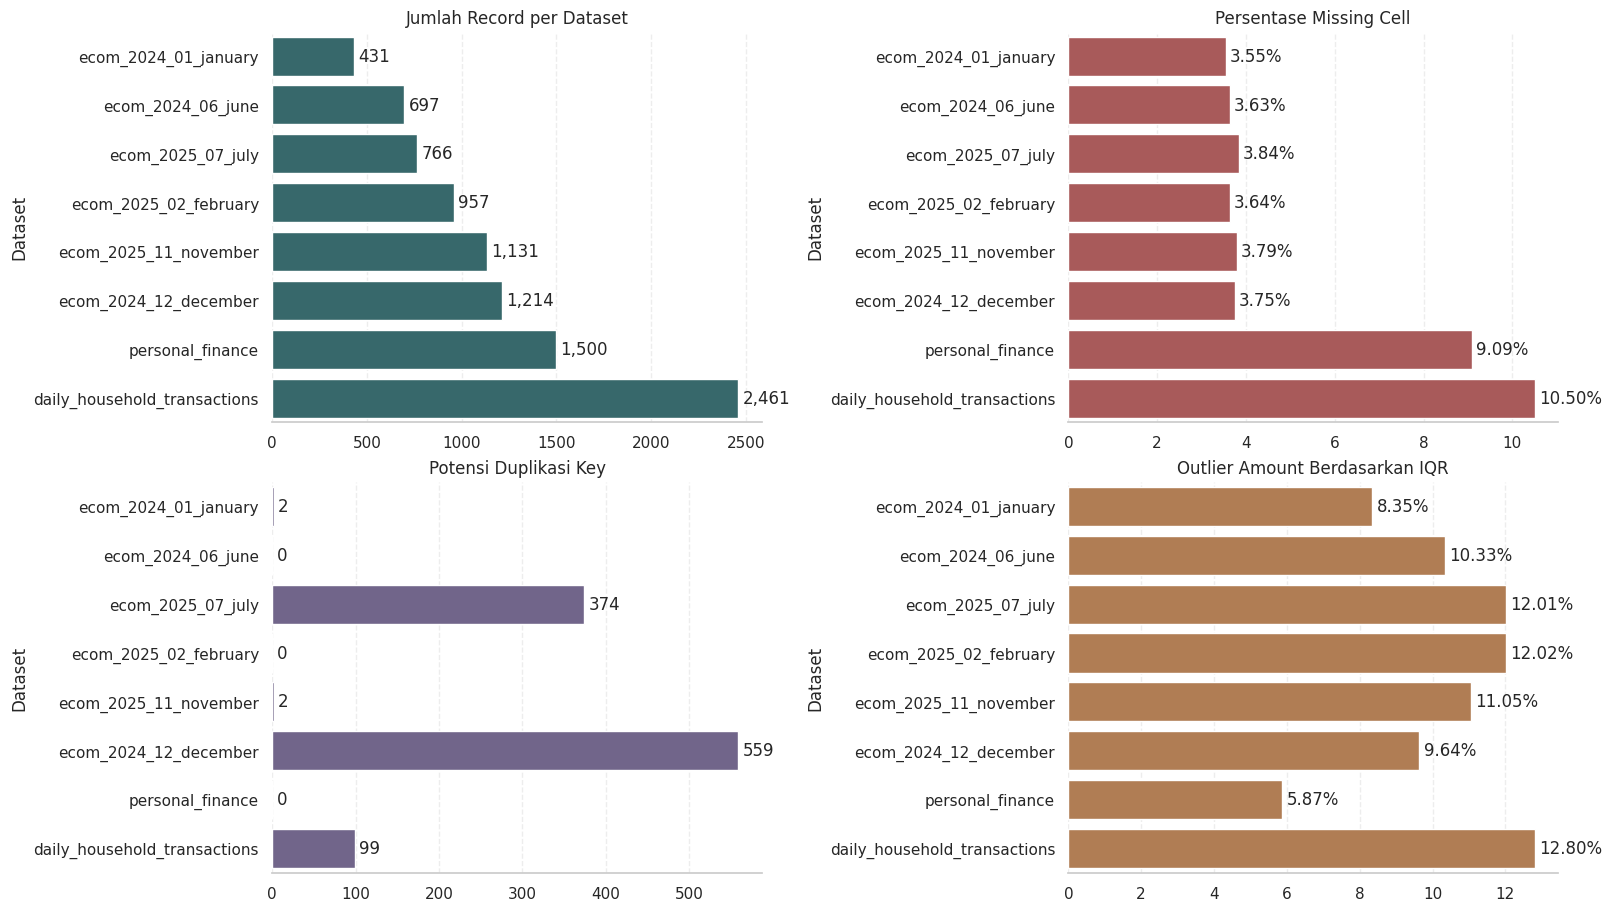

Visualisasi seaborn ditampilkan inline; tidak disimpan ke file.


In [15]:
def build_assessment_plot_frame(summary):
    plot_frame = summary.sort_values('records', ascending=True).copy()
    plot_frame['short_name'] = plot_frame['dataset_id'].str.replace('ecommerce_', 'ecom_', regex=False)
    total_cells = plot_frame['records'] * plot_frame['columns']
    plot_frame['missing_cell_pct'] = (plot_frame['missing_cells'] / total_cells * 100).replace([np.inf, -np.inf], np.nan).fillna(0)
    return plot_frame


def label_horizontal_bars(axis, formatter):
    for container in axis.containers:
        labels = [formatter(patch.get_width()) for patch in container]
        axis.bar_label(container, labels=labels, padding=3)


def draw_quality_bar(axis, data, value_col, title, color, formatter):
    sns.barplot(data=data, x=value_col, y='short_name', ax=axis, color=color)
    axis.set_title(title)
    axis.set_xlabel('')
    axis.set_ylabel('Dataset')
    axis.grid(axis='x', linestyle='--', alpha=0.35)
    axis.grid(axis='y', visible=False)
    sns.despine(ax=axis, left=True, bottom=False)
    label_horizontal_bars(axis, formatter)


def plot_assessment_quality(summary):
    plot_frame = build_assessment_plot_frame(summary)
    fig, axes = plt.subplots(2, 2, figsize=(16, 9), constrained_layout=True)
    axes = axes.ravel()

    draw_quality_bar(axes[0], plot_frame, 'records', 'Jumlah Record per Dataset', '#2f6f73', lambda value: f'{value:,.0f}')
    draw_quality_bar(axes[1], plot_frame, 'missing_cell_pct', 'Persentase Missing Cell', '#b54d4d', lambda value: f'{value:.2f}%')
    draw_quality_bar(axes[2], plot_frame, 'subset_duplicates', 'Potensi Duplikasi Key', '#6f5f90', lambda value: f'{value:,.0f}')
    draw_quality_bar(axes[3], plot_frame, 'outlier_pct', 'Outlier Amount Berdasarkan IQR', '#bf7b45', lambda value: f'{value:.2f}%')

    plt.show()


plot_assessment_quality(assessment_summary_df)
print('Visualisasi seaborn ditampilkan inline; tidak disimpan ke file.')


## Output Assessment
Tahap assessment selesai ketika `assessment_reports` dan `assessment_summary_df` sudah tersedia di memory.


## Area Analisis Mandiri
Gunakan cell kosong di bawah untuk eksplorasi kualitas data setelah semua cell utama dijalankan.

Function dan variabel yang bisa dipakai ulang:
- `detect_columns(frame)`: mencari kolom penting berdasarkan candidate name.
- `build_missing_summary(frame)`: membuat ringkasan missing value per kolom.
- `detect_outliers_iqr(series)`: mendeteksi outlier numerik memakai IQR.
- `assess_dataset(dataset_id, frame, meta)`: melakukan assessment satu dataset.
- `run_assessment(dataset_catalog, raw_datasets)`: menjalankan assessment semua dataset.
- `build_text_report(assessment_reports)`: membuat ringkasan assessment berbentuk teks.
- `plot_assessment_quality(assessment_summary_df)`: membuat visualisasi kualitas data dengan seaborn.
- `assessment_reports`: dictionary detail assessment per dataset.
- `assessment_summary_df`: dataframe ringkasan assessment semua dataset.
